<a href="https://colab.research.google.com/github/Arijit082000/LSTM-Project/blob/main/INR_Values_Prediction_Using_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import all necessary libraries
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras import Sequential
from keras.layers import Dense, LSTM

In [ ]:
#Bring the dataset from websight
df = yf.download('USDINR=X', start='2016-01-01', auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [ ]:
#Dropping first row which is stock name
df.columns = df.columns.droplevel(1)

In [ ]:
df

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2016-01-01,66.193001,66.193001,66.193001,66.150002,66.193001,0
2016-01-04,66.193001,66.193001,66.628998,66.029999,66.193001,0
2016-01-05,66.600998,66.600998,66.648003,66.400002,66.598000,0
2016-01-06,66.524002,66.524002,66.888000,66.470001,66.510002,0
2016-01-07,66.723999,66.723999,66.959999,66.519997,66.739998,0
...,...,...,...,...,...,...
2026-05-11,94.425301,94.425301,95.317596,94.181801,94.425301,0
2026-05-12,95.391403,95.391403,95.859100,95.266098,95.391403,0
2026-05-13,95.633003,95.633003,95.860497,93.604301,95.633003,0


In [ ]:
df.shape

(2698, 6)

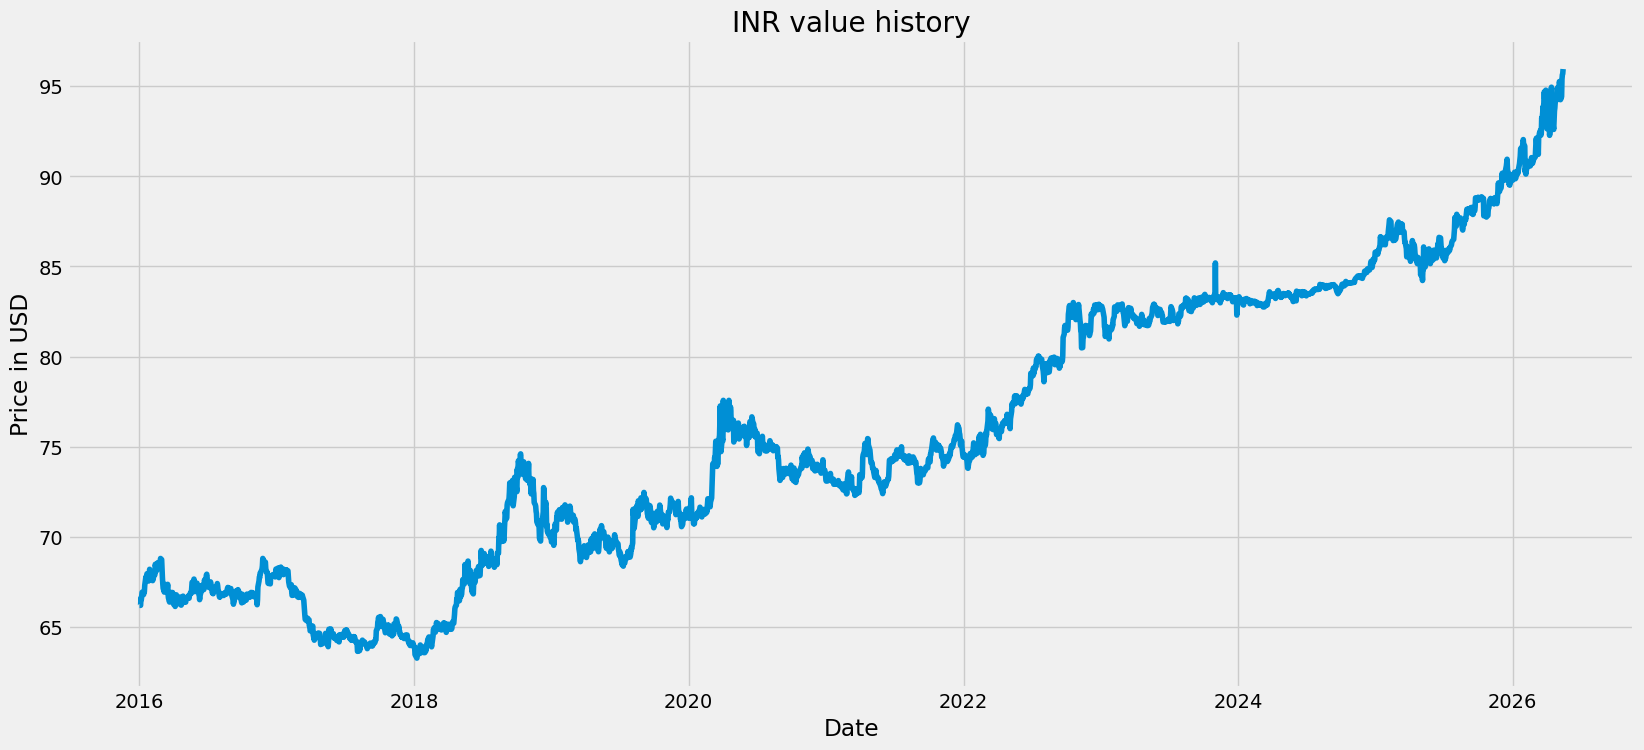

In [ ]:
plt.figure(figsize=(18,8))
plt.title('INR value history')
plt.plot(df['Close'])
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.show()

In [ ]:
data = df.filter(['Close'])
dataset = data.values
training_data_len = math.ceil(len(dataset)*.8)

In [ ]:
training_data_len

2159

In [ ]:
#Scale the data in 0 and 1
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

In [ ]:
scaled_data

array([[0.08956871],
       [0.08956871],
       [0.1020495 ],
       ...,
       [0.99014994],
       [0.99207094],
       [1.        ]])

In [ ]:
train_data = scaled_data[0:training_data_len, :]
x_train = []
y_train = []
for i in range(60, len(train_data)):
  x_train.append(train_data[i-60:i,0])
  y_train.append(train_data[i,0])
  if i<=61:
    print(x_train)
    print(y_train)
    print()

[array([0.08956871, 0.08956871, 0.1020495 , 0.09969417, 0.10581216,
       0.11183842, 0.10936056, 0.1079229 , 0.11180785, 0.11229726,
       0.12355464, 0.13771791, 0.13600486, 0.13771791, 0.14328534,
       0.13897213, 0.13080455, 0.13692253, 0.13780963, 0.15084122,
       0.1476905 , 0.14086886, 0.14123598, 0.14441726, 0.14261249,
       0.13150821, 0.13878869, 0.14717029, 0.14264306, 0.14157229,
       0.15934534, 0.14824106, 0.14903644, 0.16032416, 0.15573579,
       0.16215975, 0.16130322, 0.16240434, 0.16329144, 0.1563475 ,
       0.16922598, 0.16717662, 0.1515143 , 0.13707563, 0.12612422,
       0.11862949, 0.11211382, 0.11566222, 0.12517597, 0.11869064,
       0.12370751, 0.11159383, 0.11957797, 0.12523712, 0.10905482,
       0.10238605, 0.09516671, 0.09957164, 0.1070358 , 0.11125729])]
[np.float64(0.11141015659278586)]

[array([0.08956871, 0.08956871, 0.1020495 , 0.09969417, 0.10581216,
       0.11183842, 0.10936056, 0.1079229 , 0.11180785, 0.11229726,
       0.12355464, 0.13

In [ ]:
x_train, y_train = np.array(x_train), np.array(y_train)

In [ ]:
x_train = np.reshape(x_train,(2099,60,1))
x_train.shape

(2099, 60, 1)

In [ ]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
model.fit(x_train,y_train, batch_size=32, epochs=100)

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - loss: 0.0065
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 3.0270e-04
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 3.0471e-04
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 2.9051e-04
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 2.7238e-04
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 2.7185e-04
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - loss: 2.5017e-04
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 2.4227e-04
Epoch 9/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 2.2888e-04
Epoch 10/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 2.3001e-04
Epoch 11/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 2.1139e-04
Epoch 12/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 2.0004e-04
Epoch 13/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 1.9700e-04
Epoch 14/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 2.1013e-04
Epoch

In [ ]:
test_data = scaled_data[training_data_len-60:, :]
x_test=[]
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
  x_test.append(test_data[i-60:i,0])

In [ ]:
x_test = np.array(x_test)

In [ ]:
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1],1))

In [ ]:
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


In [ ]:
rmse = np.sqrt(np.mean((predictions - y_test)**2))
rmse

np.float64(0.3562777055829797)

In [ ]:
print("Min:", y_test.min())
print("Max:", y_test.max())

Min: 83.05220031738281
Max: 95.95500183105469


In [ ]:
train = data[:training_data_len]
valid = data[training_data_len:]
valid['predictions'] = predictions

/tmp/ipykernel_5526/1343358313.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predictions'] = predictions


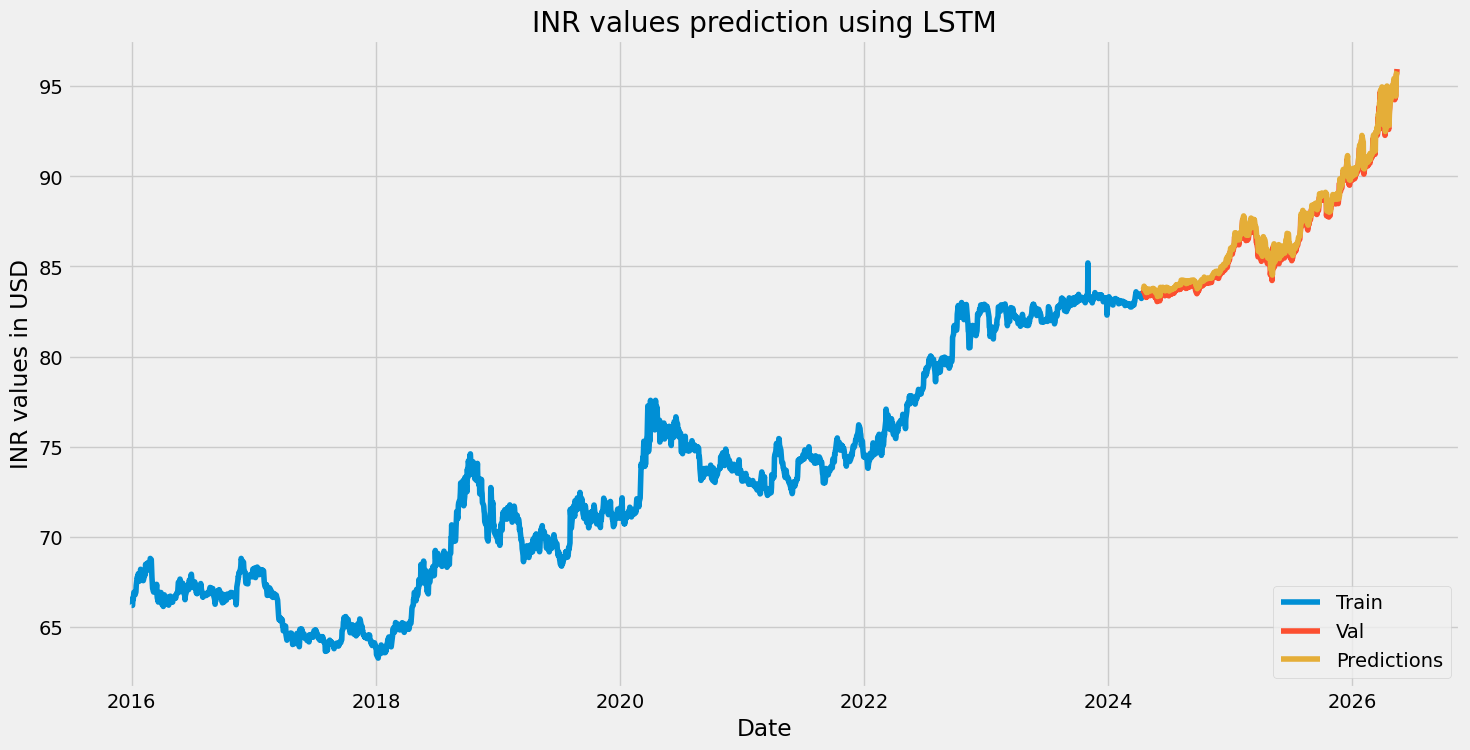

In [ ]:
plt.figure(figsize=(16,8))
plt.title('INR values prediction using LSTM')
plt.plot(train['Close'])
plt.plot(valid[['Close','predictions']])
plt.legend(['Train','Val','Predictions'], loc='lower right')
plt.xlabel('Date')
plt.ylabel('INR values in USD')
plt.show()


In [ ]:
valid

,Close,predictions
Date,,
2024-04-16,83.505997,83.844070
2024-04-17,83.667503,83.760841
2024-04-18,83.595802,83.904266
2024-04-19,83.544998,83.846153
2024-04-22,83.385300,83.799004
...,...,...
2026-05-11,94.425301,94.451103
2026-05-12,95.391403,94.668495
2026-05-13,95.633003,95.653793


In [ ]:
import yfinance as yf
# Download data
inr_quote = yf.download("USDINR=X", start="2016-01-01",auto_adjust=False)
# Select Close price
new_df = inr_quote[['Close']]
# Take last 60 days
last_60_days = new_df[-60:].values
last_60_days_scaled = scaler.transform(last_60_days)
# Multi-day (Next 5 days) prediction
future_days = 5
predictions = []
current_input = last_60_days_scaled.copy()

for i in range(future_days):

    x_test = np.reshape(current_input, (1, current_input.shape[0], 1))

    pred = model.predict(x_test, verbose=0)

    predictions.append(pred[0][0])

    # Update input sequence
    current_input = np.append(current_input, pred)[1:]
    current_input = current_input.reshape(-1, 1)

    # Inverse scale
predictions = scaler.inverse_transform(
    np.array(predictions).reshape(-1, 1)
)

# Get future dates
last_date = new_df.index[-1]

print("\nNext 5-Day Predictions:\n")

for i in range(future_days):
    next_date = last_date + pd.tseries.offsets.BDay(i+1)
    print(f"{next_date.date()}  →  ${predictions[i][0]:.4f}")

[*********************100%***********************]  1 of 1 completed



Next 5-Day Predictions:

2026-05-18  →  $96.0857
2026-05-19  →  $96.1890
2026-05-20  →  $96.2975
2026-05-21  →  $96.4110
2026-05-22  →  $96.5302


In [ ]:
inr_quote2 = yf.download("USDINR=X", start="2016-01-01",auto_adjust=False)
print(inr_quote2['Close'].iloc[-1])

[*********************100%***********************]  1 of 1 completed

Ticker
USDINR=X    95.955002
Name: 2026-05-15 00:00:00, dtype: float64
